# 00 · Main Results (Exp3) — thesis-artifact entry point

Run this notebook to (re)generate the **canonical figures + tables** for the thesis writeup. Everything
here is exported to `results/figures/` (PDF + PNG) and `results/tables/` (CSV + LaTeX booktabs + MD)
via `exp3.save_fig` / `exp3.save_table`. The deeper exploratory analyses live in `01`/`02`/`03`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, figures
figures.set_style()
ARMS   = exp3.discover_arms()
SCORES = exp3.load_scores_long(ARMS)
PALETTE = figures.arm_palette(sorted(SCORES.arm.unique()))
METRICS = [m for m in exp3.QUESTIONNAIRE_ORDER if m in SCORES.questionnaire.unique()]
ORACLE_NOISE = 0.10   # oracle reproducibility band (~0.07-0.10 |Δ|, partial-conv EDA): min meaningful diff
print("arms on disk:", [(a.label, len(a.iters)) for a in ARMS])
print("scores_long:", SCORES.shape, "| arms scored:", sorted(SCORES.arm.unique()))
print("exports ->", exp3.RESULTS_DIR)

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 2), ('GRPO_LA0', 4), ('GRPO_LA5', 2)]
scores_long: (12096, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Main results table + repeated-measures omnibus
Per (arm × rubric): final vs base, paired Cohen's dz + label, Wilcoxon p (Holm), bootstrap CI, trajectory ρ/slope. Friedman = matched-persona omnibus across iterations (Kendall's W effect size).

In [2]:
MR = stats.main_results_table(SCORES, target="final")
display(MR)
exp3.save_table(MR, "main_results_final", caption="Final iteration vs base, per arm x rubric. Paired by persona (N=96): dz, Wilcoxon p (Holm), bootstrap 95% CI, trajectory Spearman rho/OLS slope.")

FR = pd.DataFrame([stats.friedman_trajectory(SCORES, a, m)
                   for a in sorted(SCORES.arm.unique()) for m in METRICS])
display(FR.round(4))
exp3.save_table(FR.round(4), "friedman_omnibus", caption="Friedman repeated-measures omnibus across iterations per arm x rubric (Kendall's W effect size); N personas matched.")

,arm,rubric,base,target_iter,target,delta,dz,effect,wilcoxon_p,ci_low,ci_high,traj_rho,traj_slope,p_holm
0,GRPO_LA0,Q1Q2,3.067,3,3.993,0.927,1.149,large,0.0000,0.769,1.087,0.272,0.2870,0.0000
1,GRPO_LA0,WAI-SR,2.890,3,3.301,0.411,0.607,medium,0.0000,0.279,0.544,0.143,0.1263,0.0000
2,GRPO_LA0,CSQ-8,2.362,3,2.811,0.449,0.683,medium,0.0000,0.312,0.581,0.132,0.1385,0.0000
3,GRPO_LA0,MI-SAT,2.710,3,3.290,0.580,0.645,medium,0.0000,0.398,0.762,0.142,0.1812,0.0000
4,GRPO_LA0,MITI,3.224,3,3.938,0.714,0.923,large,0.0000,0.562,0.870,0.274,0.2352,0.0000
5,GRPO_LA0,Q1,3.021,3,3.935,0.915,1.133,large,0.0000,0.760,1.075,0.248,0.2869,0.0000
6,GRPO_LA0,Q2,3.113,3,4.051,0.939,1.074,large,0.0000,0.768,1.115,0.288,0.2872,0.0000
7,PTO_LA0,Q1Q2,3.000,10,4.260,1.259,1.429,large,0.0000,1.086,1.434,0.353,0.1203,0.0000
8,PTO_LA0,WAI-SR,2.845,10,3.497,0.653,0.968,large,0.0000,0.525,0.786,0.226,0.0687,0.0000
9,PTO_LA0,CSQ-8,2.384,10,2.945,0.561,0.805,large,0.0000,0.419,0.701,0.171,0.0587,0.0000


,arm,metric,chi2,p,kendall_w,k_iters,n_personas
0,GRPO_LA0,Q1Q2,104.4452,0.0,0.3627,4,96
1,GRPO_LA0,WAI-SR,26.8409,0.0,0.0932,4,96
2,GRPO_LA0,CSQ-8,35.3893,0.0,0.1229,4,96
3,GRPO_LA0,MI-SAT,35.0384,0.0,0.1217,4,96
4,GRPO_LA0,MITI,73.8057,0.0,0.2563,4,96
5,GRPO_LA0,Q1,97.0579,0.0,0.3370,4,96
6,GRPO_LA0,Q2,77.4383,0.0,0.2689,4,96
7,GRPO_LA5,Q1Q2,NaN,NaN,NaN,1,96
8,GRPO_LA5,WAI-SR,NaN,NaN,NaN,1,96
9,GRPO_LA5,CSQ-8,NaN,NaN,NaN,1,96


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

## 2 · Headline outcome figure — best iteration per arm across the 6 rubrics

,arm,oracle,judged_by,best_iteration,best_model,own_oracle_mean,n
0,GRPO_LA0,Q1Q2,Q1Q2,3,GRPOExp3_LA0_I3,3.9934,96
1,PTO_LA0,Q1Q2,Q1Q2,10,PTOExp3_LA0_I10,4.2597,96
2,PTO_LA5,Q1Q2,Q1Q2,1,PTOExp3_LA5_I1,3.1808,96


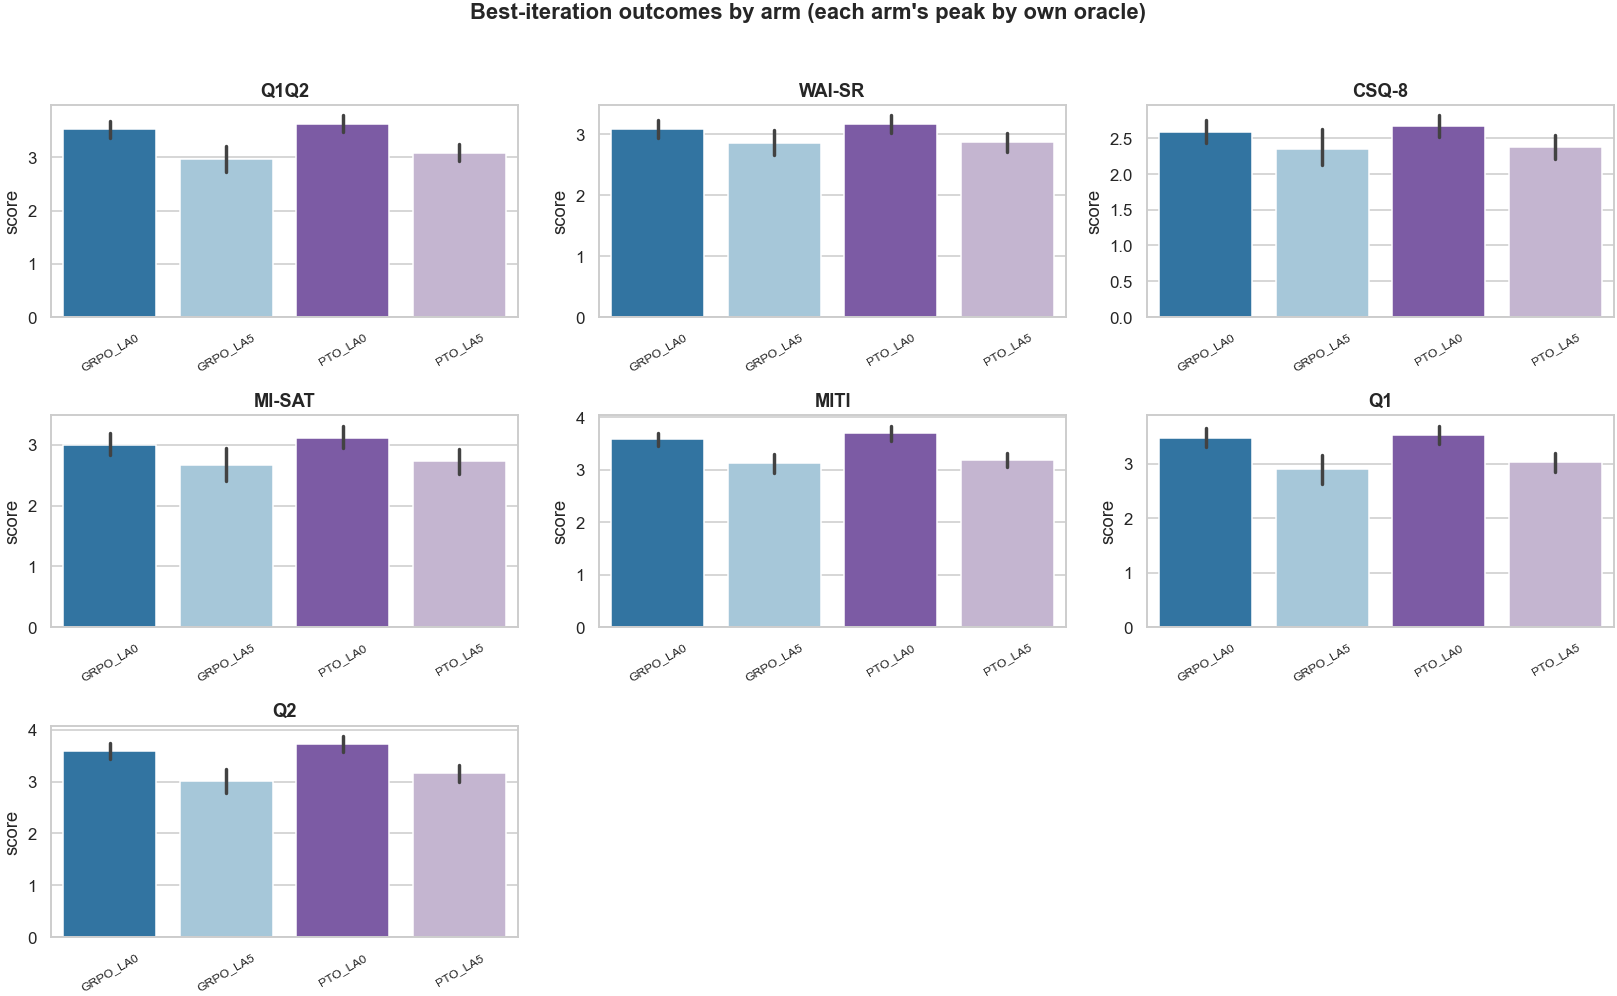

In [3]:
SEL, best = exp3.best_per_experiment(SCORES); display(best)
fig, axes = figures.grid(len(METRICS), ncols=3, panel=(5.0, 3.0))
for ax, m in zip(axes, METRICS):
    sns.barplot(SEL[SEL.questionnaire==m], x="arm", y="score", hue="arm",
                order=sorted(SEL.arm.unique()), palette=PALETTE, errorbar=("ci",95), ax=ax)
    ax.set_title(m); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30, labelsize=8)
    if ax.get_legend(): ax.legend_.remove()
fig.suptitle("Best-iteration outcomes by arm (each arm's peak by own oracle)", y=1.02, fontweight="bold")
fig.tight_layout(); exp3.save_fig(fig, "outcomes_headline", caption="Best iteration per arm (peak by own training oracle) across the 6 MI rubrics; mean +/- 95% CI over 96 personas.")
plt.show()

## 3 · Q1+Q2 learning curve with oracle-noise reference band

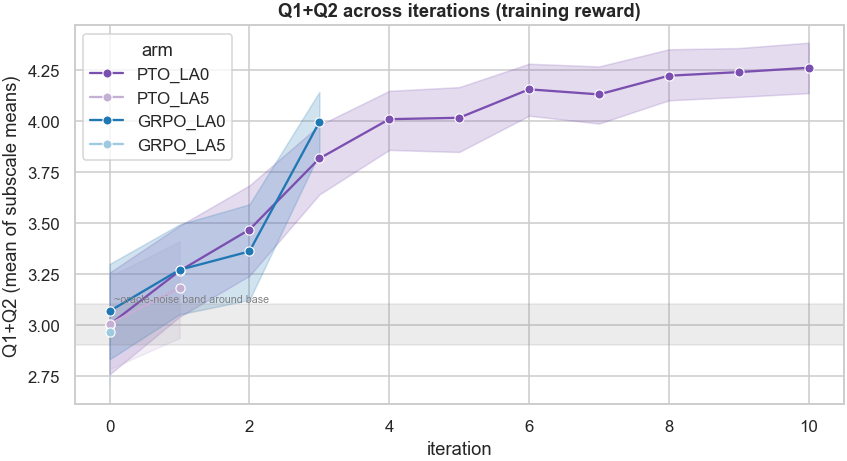

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(SCORES[SCORES.questionnaire=="Q1Q2"], x="iteration", y="score", hue="arm",
             palette=PALETTE, marker="o", errorbar=("ci",95), ax=ax)
base0 = SCORES[(SCORES.arm=="PTO_LA0")&(SCORES.is_base)&(SCORES.questionnaire=="Q1Q2")]["score"].mean()
ax.axhspan(base0-ORACLE_NOISE, base0+ORACLE_NOISE, color="grey", alpha=0.15)
ax.text(0.02, base0+ORACLE_NOISE, " ~oracle-noise band around base", fontsize=7, va="bottom", color="grey")
ax.set_title("Q1+Q2 across iterations (training reward)"); ax.set_xlabel("iteration"); ax.set_ylabel("Q1+Q2 (mean of subscale means)")
fig.tight_layout(); exp3.save_fig(fig, "trajectory_Q1Q2", caption="Q1+Q2 mean across iterations per arm (mean +/- 95% CI, N=96). Grey band = oracle reproducibility (~0.10) around the PTO base: differences within it are at oracle-noise scale.")
plt.show()

## 4 · Reward faithfulness + rubric factor structure

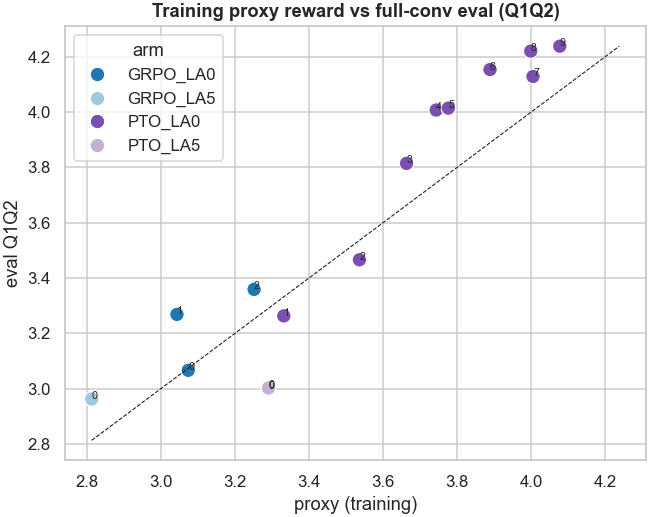

,arm,PC1_%
0,GRPO_LA0,92.9
1,GRPO_LA5,93.9
2,PTO_LA0,90.7
3,PTO_LA5,90.9


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

In [5]:
GENS = training.load_generations(ARMS)
proxy = GENS.groupby(["arm","eval_iter"])["score"].mean().rename("proxy").reset_index().rename(columns={"eval_iter":"iteration"})
evalq = SCORES[SCORES.questionnaire=="Q1Q2"].groupby(["arm","iteration"])["score"].mean().rename("eval").reset_index()
faith = proxy.merge(evalq, on=["arm","iteration"])
fig, ax = plt.subplots(figsize=(6.2,5))
sns.scatterplot(faith, x="proxy", y="eval", hue="arm", s=90, palette=figures.arm_palette(sorted(faith.arm.unique())), ax=ax)
for _, r in faith.iterrows(): ax.annotate(int(r.iteration),(r.proxy,r.eval),fontsize=7)
lo,hi=faith[["proxy","eval"]].min().min(),faith[["proxy","eval"]].max().max(); ax.plot([lo,hi],[lo,hi],"k--",lw=.7)
ax.set_title("Training proxy reward vs full-conv eval (Q1Q2)"); ax.set_xlabel("proxy (training)"); ax.set_ylabel("eval Q1Q2")
fig.tight_layout(); exp3.save_fig(fig, "faithfulness_proxy_vs_eval", caption="Per (arm, iteration): mean training proxy reward (oracle on short branch, K=0) vs full-conversation eval Q1Q2; dashed y=x.")
plt.show()
pca_rows = [{"arm":a, **{"PC1_%":round(100*stats.rubric_pca(SCORES[SCORES.arm==a])["explained_variance_ratio"][0],1)}}
            for a in sorted(SCORES.arm.unique()) if stats.rubric_pca(SCORES[SCORES.arm==a])["explained_variance_ratio"]]
PCA = pd.DataFrame(pca_rows); display(PCA)
exp3.save_table(PCA, "rubric_pca_pc1", caption="Variance explained by PC1 of the 6 rubric scores per arm (a dominant PC1 => rubrics ~ one latent factor).")

## 5 · Preference probe headline (PTO) — which words the policy prefers

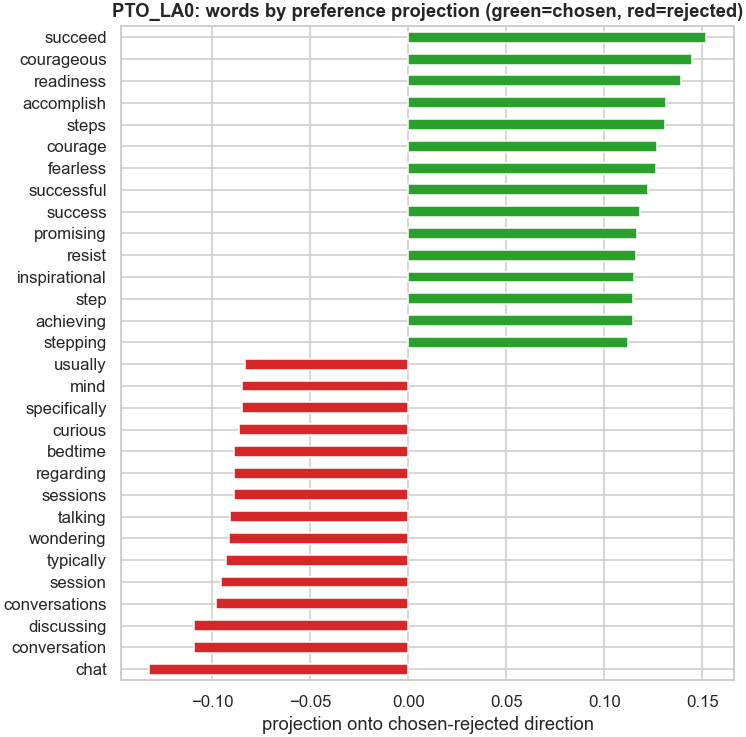

In [6]:
from exp3 import pref
pto = [a for a in ARMS if a.method=="PTO" and len(training.load_pref_pairs([a]))]
if pto:
    arm = pto[0]; PAIRS = pref.add_text_features(training.load_pref_pairs([arm])); EMB = pref.embed_pairs(PAIRS)
    DIRS = pref.preference_direction_by_iter(EMB)
    words, wmat = pref.embed_vocab(pref.build_vocab(PAIRS, top_n=3000)); WP = pref.word_projection(words, wmat, DIRS)
    top = WP.sort_values("mean", ascending=False).head(15).index.tolist() + WP.sort_values("mean").head(15).index.tolist()
    s = WP.loc[top, "mean"].sort_values()
    fig, ax = plt.subplots(figsize=(7, 7)); s.plot.barh(ax=ax, color=(s>0).map({True:"#2ca02c", False:"#d62728"}))
    ax.set_title(f"{arm.label}: words by preference projection (green=chosen, red=rejected)"); ax.set_xlabel("projection onto chosen-rejected direction")
    fig.tight_layout(); exp3.save_fig(fig, "pref_word_ranking", caption=f"{arm.label}: top words aligned with the chosen (green) vs rejected (red) preference direction (Mass Mean Probe, pooled over iterations).")
    plt.show()
else:
    print("No PTO arm with preference pairs scored yet.")

## 6 · Takeaways (thesis)
- _(headline numbers, effect sizes, the faithfulness + PC1 story; fill for the writeup)_